<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/03_naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import numpy as np
from scipy.sparse import load_npz
import pandas as pd

# Upload the saved files from preprocessing
uploaded = files.upload()  # Upload X_train.npz, X_test.npz, y_train.npy, y_test.npy

X_train = load_npz('X_train.npz')
X_test = load_npz('X_test.npz')
y_train = np.load('y_train.npy', allow_pickle=True)
y_test = np.load('y_test.npy', allow_pickle=True)

print("Data loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Saving X_test.npz to X_test.npz
Saving X_train.npz to X_train.npz
Saving y_test.npy to y_test.npy
Saving y_train.npy to y_train.npy
Data loaded successfully!
X_train shape: (4135, 5000)
X_test shape: (1034, 5000)


In [2]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("Naïve Bayes model trained successfully!")

Naïve Bayes model trained successfully!


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = nb_model.predict(X_test)

print("=== Naïve Bayes Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred, pos_label='spam'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Naïve Bayes Results ===
Accuracy:  0.9681
Precision: 1.0000
Recall:    0.7481
F1 Score:  0.8559

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       1.00      0.75      0.86       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.97      1034



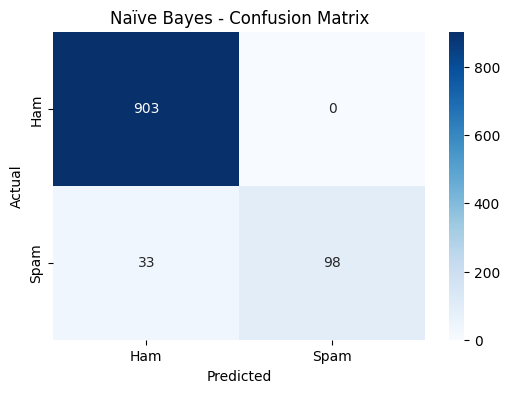

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Naïve Bayes - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('nb_confusion_matrix.png')
plt.show()

In [5]:
nb_results = {
    'model': 'Naive Bayes',
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, pos_label='spam'),
    'recall': recall_score(y_test, y_pred, pos_label='spam'),
    'f1': f1_score(y_test, y_pred, pos_label='spam')
}

import json
with open('nb_results.json', 'w') as f:
    json.dump(nb_results, f)

print("Results saved!")
print(nb_results)

Results saved!
{'model': 'Naive Bayes', 'accuracy': 0.9680851063829787, 'precision': 1.0, 'recall': 0.7480916030534351, 'f1': 0.8558951965065502}
